# MVP do Sprint Análise de Dados e Boas Práticas

- **Aluno:** Diogo Reis Beltrão Lessa
- **Matrícula:** 4052025002548  
- **Curso:** Pós-Graduação em Ciência de Dados e Analytics - PUC-Rio

---

## Dataset

**Credit Card Customers (BankChurners)**  
Fonte: [Kaggle - sakshigoyal7/credit-card-customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)

| Característica | Valor |
|---|---|
| Registros | `10.127` clientes |
| Variáveis originais | 23 (21 utilizáveis) |
| Variável-alvo | `Attrition_Flag` (Existing Customer / Attrited Customer) |


---

## Objetivo

Analisar o perfil e o comportamento de clientes de cartão de crédito para identificar os fatores mais associados ao **churn** (cancelamento do cartão), aplicando técnicas de análise exploratória de dados (EDA) e pré-processamento.

# Descrição do Problema

O dataset **Credit Card Customers (BankChurners)**, disponível no Kaggle, simula o cenário de um banco que observa uma taxa de cancelamento de aproximadamente **`16%`** nos cartões de crédito. Segundo a descrição original do dataset, o contexto é o de um gerente bancário que precisa prever quais clientes vão cancelar seus cartões para poder atuar preventivamente na retenção.

A taxa de `~16%` é derivada da própria distribuição da variável-alvo no dataset: aproximadamente **`1.627` clientes classificados como "Attrited Customer"** em um total de **`10.127` registros**. Os demais `~8.500` clientes permanecem ativos ("Existing Customer").

O objetivo deste trabalho é identificar, por meio de **análise exploratória de dados (EDA) e pré-processamento**, quais características dos clientes estão mais associadas ao churn, preparando os dados para um futuro modelo preditivo de retenção. A etapa de modelagem não faz parte do escopo deste MVP.

## Hipóteses do Problema

Com base no domínio de negócio e nas variáveis disponíveis, levantamos as seguintes hipóteses a serem investigadas e respondidas ao longo deste notebook:

**H1: Inatividade e churn**  
Clientes com mais meses de inatividade nos últimos 12 meses (`Months_Inactive_12_mon`) apresentam maior taxa de cancelamento do cartão.

**H2: Utilização do crédito e churn**  
Clientes com baixa taxa de utilização do limite de crédito (`Avg_Utilization_Ratio`) têm maior propensão ao churn, indicando desengajamento com o produto.

**H3: Número de produtos bancários e churn**  
Clientes com menor número de produtos contratados com o banco (`Total_Relationship_Count`) cancelam o cartão com maior frequência, sugerindo menor vínculo com a instituição.

**H4: Faixa de renda e churn**  
A faixa de renda do cliente (`Income_Category`) influencia a probabilidade de cancelamento - clientes de renda mais baixa podem ter maior pressão financeira para cancelar, enquanto clientes de renda alta podem buscar produtos mais vantajosos em outros bancos.

**H5: Redução de transações e churn**  
Clientes que reduziram sua contagem de transações do Q1 para o Q4 (`Total_Ct_Chng_Q4_Q1` com valores menores indicando queda) apresentam maior risco de cancelamento, revelando uma mudança comportamental que precede o churn.

## Tipo de Problema

Trata-se de um problema de **classificação supervisionada binária**:

- **Variável-alvo:** `Attrition_Flag`
  - `"Existing Customer"` → cliente ativo (classe majoritária, `~84%`)
  - `"Attrited Customer"` → cliente que cancelou (classe minoritária, `~16%`)

O **escopo deste MVP** abrange exclusivamente as etapas de **Análise Exploratória de Dados (EDA)** e **Pré-Processamento**. A etapa de modelagem preditiva (treinamento e avaliação de classificadores) é um próximo passo natural, mas está fora do escopo atual.

O desbalanceamento de classes (`~84%/16%`) é uma característica relevante que será discutida ao longo do notebook e deverá ser tratada na etapa de modelagem futura.

## Seleção de Dados

**Fonte:** Kaggle - [Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers), publicado por sakshigoyal7.

**Dimensões:** `10.127` instâncias × `23` colunas originais (`20` utilizáveis após remoção de `CLIENTNUM` e das `2` colunas de saída do Naive Bayes inseridas pelo autor do dataset).

**Justificativa para a escolha deste dataset:**

- **Riqueza de variáveis:** mistura equilibrada de variáveis numéricas (`14`) e categóricas (`5`), exigindo diferentes estratégias de encoding e pré-processamento.
- **Missing values disfarçados:** a categoria `"Unknown"` presente em três colunas (`Education_Level`, `Marital_Status`, `Income_Category`) representa um caso realista de dado faltante implícito - comum em datasets de negócio.
- **Desbalanceamento de classes:** a proporção `~84%/16%` é típica de problemas de churn e exige atenção especial, sendo um excelente exercício de análise crítica.
- **Contexto de negócio claro:** o problema de retenção de clientes é relevante e bem delimitado, facilitando a formulação de hipóteses e a interpretação dos resultados.
- **Potencial para múltiplas técnicas:** o dataset é adequado para demonstrar normalização, padronização, encoding ordinal, One-Hot Encoding (OHE), detecção de outliers, transformação logarítmica e feature engineering.

## Atributos do Dataset

O dataset original possui `23` colunas. Após remoção de `CLIENTNUM` (identificador sem valor preditivo) e das `2` últimas colunas (outputs do modelo Naive Bayes inseridos pelo autor), restam **`20` variáveis utilizáveis**:

| # | Variável | Tipo | Descrição |
|---|---|---|---|
| 1 | `Attrition_Flag` | Categórica (target) | Status do cliente: `"Existing Customer"` ou `"Attrited Customer"` |
| 2 | `Customer_Age` | Numérica (int) | Idade do cliente em anos |
| 3 | `Gender` | Categórica binária | Gênero: `M` ou `F` |
| 4 | `Dependent_count` | Numérica (int) | Número de dependentes (0-5) |
| 5 | `Education_Level` | Categórica ordinal | Escolaridade: `Uneducated`, `High School`, `College`, `Graduate`, `Post-Graduate`, `Doctorate`, **Unknown** |
| 6 | `Marital_Status` | Categórica nominal | Estado civil: `Married`, `Single`, `Divorced`, **Unknown** |
| 7 | `Income_Category` | Categórica ordinal | Faixa de renda: `Less than $40K`, `$40K - $60K`, `$60K - $80K`, `$80K - $120K`, `$120K +`, **Unknown** |
| 8 | `Card_Category` | Categórica ordinal | Tipo de cartão: `Blue`, `Silver`, `Gold`, `Platinum` |
| 9 | `Months_on_book` | Numérica (int) | Tempo como cliente do banco (em meses) |
| 10 | `Total_Relationship_Count` | Numérica (int) | Total de produtos contratados com o banco (1-6) |
| 11 | `Months_Inactive_12_mon` | Numérica (int) | Meses inativos nos últimos 12 meses |
| 12 | `Contacts_Count_12_mon` | Numérica (int) | Número de contatos com o banco nos últimos 12 meses |
| 13 | `Credit_Limit` | Numérica (float) | Limite de crédito do cartão |
| 14 | `Total_Revolving_Bal` | Numérica (int) | Saldo rotativo total (quanto o cliente deve no cartão) |
| 15 | `Avg_Open_To_Buy` | Numérica (float) | Limite disponível médio (Credit_Limit − Total_Revolving_Bal) |
| 16 | `Total_Amt_Chng_Q4_Q1` | Numérica (float) | Variação do valor transacionado entre Q4 e Q1 |
| 17 | `Total_Trans_Amt` | Numérica (int) | Valor total transacionado no período |
| 18 | `Total_Trans_Ct` | Numérica (int) | Contagem total de transações no período |
| 19 | `Total_Ct_Chng_Q4_Q1` | Numérica (float) | Variação da contagem de transações entre Q4 e Q1 |
| 20 | `Avg_Utilization_Ratio` | Numérica (float) | Taxa média de utilização do crédito (0.0-1.0) |



> **Nota sobre "Unknown":** As colunas `Education_Level`, `Marital_Status` e `Income_Category` contêm a categoria `"Unknown"` como proxy de valores faltantes. As quantidades exatas serão calculadas a partir do CSV na etapa de EDA (Bloco 4). Serão avaliadas três estratégias de tratamento no pré-processamento (Bloco 5).

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção centraliza todos os imports do projeto e o carregamento do dataset. Manter os imports em um único bloco é uma boa prática que facilita a leitura, evita dependências ocultas entre células e simplifica a adaptação do notebook para outros ambientes.

As bibliotecas utilizadas cobrem:
- **Manipulação de dados:** `pandas`, `numpy`
- **Visualização:** `matplotlib`, `seaborn`
- **Pré-processamento:** `scikit-learn` (scalers, encoders, split)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Configurações globais de visualização
sns.set_theme(style='whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [31]:
# Carregamento do dataset a partir do repositório GitHub
url = 'https://raw.githubusercontent.com/diogorblessa/mvp-credit-card-churn/main/data/BankChurners.csv'
df = pd.read_csv(url)

print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dataset carregado: 10127 linhas x 23 colunas


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## Limpeza Inicial

Antes de iniciar qualquer análise, removemos as colunas que não devem fazer parte do dataset utilizável:

1. **`CLIENTNUM`**: é apenas um número de identificação do cliente, como um número de matrícula. Ele não diz nada sobre o comportamento ou perfil da pessoa. Se mantivermos essa coluna, algoritmos de machine learning podem tratá-la como uma variável numérica comum e encontrar padrões falsos, como associar determinadas faixas de IDs a churn por pura coincidência. Isso prejudicaria a capacidade do modelo de funcionar com dados novos.

2. **Colunas `Naive_Bayes_Classifier_*` (as 2 últimas)**: são outputs de um modelo que foram inseridas pelo autor do dataset e contêm o resultado de um modelo já treinado para prever churn. Ou seja, essas colunas já carregam a resposta que queremos descobrir.

Após a remoção, verificamos a presença de **linhas duplicadas**, que poderiam distorcer estatísticas e pesos em modelagem futura.

In [32]:
# Remover CLIENTNUM (identificador sem valor preditivo)
df = df.drop(columns=['CLIENTNUM'])

# Remover as 2 últimas colunas (outputs do Naive Bayes inseridos pelo autor do dataset)
colunas_naive_bayes = [col for col in df.columns if col.startswith('Naive_Bayes_Classifier_')]
print(f"Colunas Naive Bayes removidas: {colunas_naive_bayes}")
df = df.drop(columns=colunas_naive_bayes)

# Verificar duplicatas
n_duplicatas = df.duplicated().sum()
print(f"\nLinhas duplicadas: {n_duplicatas}")

# Shape final
print(f"\nShape após limpeza: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Colunas restantes: {list(df.columns)}")
df.head()

Colunas Naive Bayes removidas: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

Linhas duplicadas: 0

Shape após limpeza: 10127 linhas × 20 colunas
Colunas restantes: ['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


# Análise de Dados

A Análise Exploratória de Dados (EDA) é a etapa em que investigamos a estrutura, distribuição e relacionamentos do dataset antes de qualquer modelagem. Seu objetivo é compreender o que os dados dizem, identificar padrões, anomalias e possíveis problemas de qualidade, e gerar hipóteses que serão testadas ao longo do notebook.

Neste bloco, a EDA está organizada nas seguintes subseções:
1. **Total e tipo das instâncias**, quantidade de registros, tipos de variáveis e distribuição do target
2. **Estatísticas descritivas**, média, desvio padrão, quartis e escala das variáveis numéricas
3. **Histogramas**, distribuição de frequência das variáveis numéricas
4. **Distribuição das variáveis categóricas**, frequência de cada categoria
5. **Boxplots por grupo**, comparação entre clientes ativos e cancelados
6. **Análises bivariadas**, cruzamento das categóricas com o target
7. **Matriz de correlação**, relacionamentos entre variáveis numéricas
8. **Valores nulos e "Unknown"**, identificação de dados faltantes explícitos e implícitos

## Total e Tipo das Instâncias

Antes de analisar os dados, é fundamental entender sua estrutura: quantas instâncias (linhas) e variáveis (colunas) temos, quais são os tipos de cada variável e se existe algum problema óbvio de tipo ou formato.

Após a limpeza inicial realizada no Bloco 3, o dataset possui:
- **`10.127` instâncias** (clientes)
- **`20` variáveis** utilizáveis: `14` numéricas e `6` categóricas (incluindo o target `Attrition_Flag`)

In [33]:
# Total de instâncias e estrutura geral
print(f"Total de instâncias: {len(df)}")
print(f"Total de colunas: {df.shape[1]}")
print()

# Contagem por tipo
n_numericas = df.select_dtypes(include='number').shape[1]
n_categoricas = df.select_dtypes(include='object').shape[1]
print(f"Variáveis numéricas: {n_numericas}")
print(f"Variáveis categóricas (incl. target): {n_categoricas}")
print()

# Tipos de cada coluna
print("Tipos de dados por coluna:")
print(df.dtypes)
print()

# Visão geral completa
df.info()

Total de instâncias: 10127
Total de colunas: 20

Variáveis numéricas: 14
Variáveis categóricas (incl. target): 6

Tipos de dados por coluna:
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column    

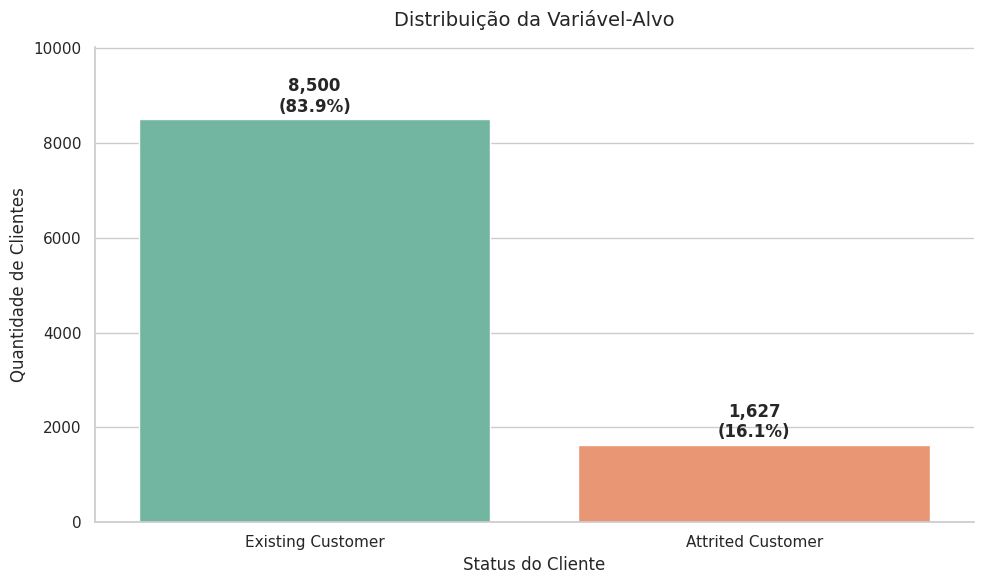

In [34]:
# Distribuição da variável-alvo (Attrition_Flag)
fig, ax = plt.subplots(figsize=(10, 6))

ordem_target = ['Existing Customer', 'Attrited Customer']
sns.countplot(x='Attrition_Flag', data=df, palette='Set2', ax=ax,
              order=ordem_target)

# Anotar percentuais e contagens sobre cada barra
total = len(df)
for p in ax.patches:
    valor = int(p.get_height())
    pct = valor / total * 100
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 80,
        f'{valor:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_title('Distribuição da Variável-Alvo', fontsize=14, pad=15)
ax.set_xlabel('Status do Cliente', fontsize=12)
ax.set_ylabel('Quantidade de Clientes', fontsize=12)
ax.set_ylim(0, df['Attrition_Flag'].value_counts().max() * 1.18)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


O gráfico mostra que o dataset tem muito mais clientes ativos do que cancelados: **`8.500` clientes ativos (`83,93%`)** contra **`1.627` que cancelaram o cartão (`16,07%`)**. Essa diferença de proporção, cerca de 5 clientes ativos para cada 1 que cancelou, é chamada de **desbalanceamento entre classes** e é muito comum em problemas de churn.

Isso tem uma consequência prática importante: ao cruzar a variável-alvo com outras variáveis nas próximas análises, precisamos sempre comparar **proporções** (taxas percentuais) em vez de quantidades absolutas. Por exemplo, dizer que "500 clientes ativos têm renda alta" não significa muito se não compararmos com a proporção dos que cancelaram com a mesma renda, do contrário, o grupo maior vai sempre parecer mais relevante só por ser maior.

Na etapa de modelagem futura (fora do escopo deste MVP), esse desbalanceamento também precisará ser tratado para que o modelo não aprenda simplesmente a dizer que todo cliente é ativo, o que daria `84%` de acerto mas não identificaria nenhum cancelamento, tornando o modelo inútil na prática.

## Estatísticas Descritivas

As estatísticas descritivas fornecem um resumo quantitativo das variáveis numéricas do dataset, incluindo:
- **Média (`mean`)**, valor central da distribuição
- **Desvio padrão (`std`)**, dispersão em torno da média
- **Mínimo e máximo**, amplitude da variável
- **Quartis (`25%`, `50%`, `75%`)**, distribuição e presença de assimetria

O método `df.describe()` do pandas gera esse resumo automaticamente para todas as colunas numéricas.

In [35]:
# Resumo estatístico completo das variáveis numéricas
df.describe().round(2)

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


### Média

A média aritmética representa o valor central de cada variável. Ela é útil para ter uma primeira impressão do dataset, mas pode ser enganosa quando a distribuição é assimétrica, nesses casos, a mediana (percentil `50%`) é mais representativa.

Observações a partir do `describe()`:
- **`Customer_Age`**, média de `46,33` anos, indicando uma base de clientes madura
- **`Credit_Limit`**, média de `R$ 8.631,95`, mas com desvio padrão de `R$ 9.088,78` (maior que a própria média), sinalizando forte assimetria à direita
- **`Avg_Open_To_Buy`**, média de `R$ 7.469,14` com desvio de `R$ 9.090,69`, padrão similar ao `Credit_Limit`, o que faz sentido pois as duas variáveis são matematicamente relacionadas
- **`Total_Trans_Ct`**, média de `64,86` transações, com mediana de `67`, distribuição relativamente simétrica
- **`Avg_Utilization_Ratio`**, média de `0,27` indica que, em geral, os clientes utilizam apenas `27%` do limite disponível

In [36]:
# Médias das variáveis numéricas
medias = df.describe().loc['mean'].round(2)
print("Médias das variáveis numéricas:")
print(medias)

Médias das variáveis numéricas:
Customer_Age                  46.33
Dependent_count                2.35
Months_on_book                35.93
Total_Relationship_Count       3.81
Months_Inactive_12_mon         2.34
Contacts_Count_12_mon          2.46
Credit_Limit                8631.95
Total_Revolving_Bal         1162.81
Avg_Open_To_Buy             7469.14
Total_Amt_Chng_Q4_Q1           0.76
Total_Trans_Amt             4404.09
Total_Trans_Ct                64.86
Total_Ct_Chng_Q4_Q1            0.71
Avg_Utilization_Ratio          0.27
Name: mean, dtype: float64


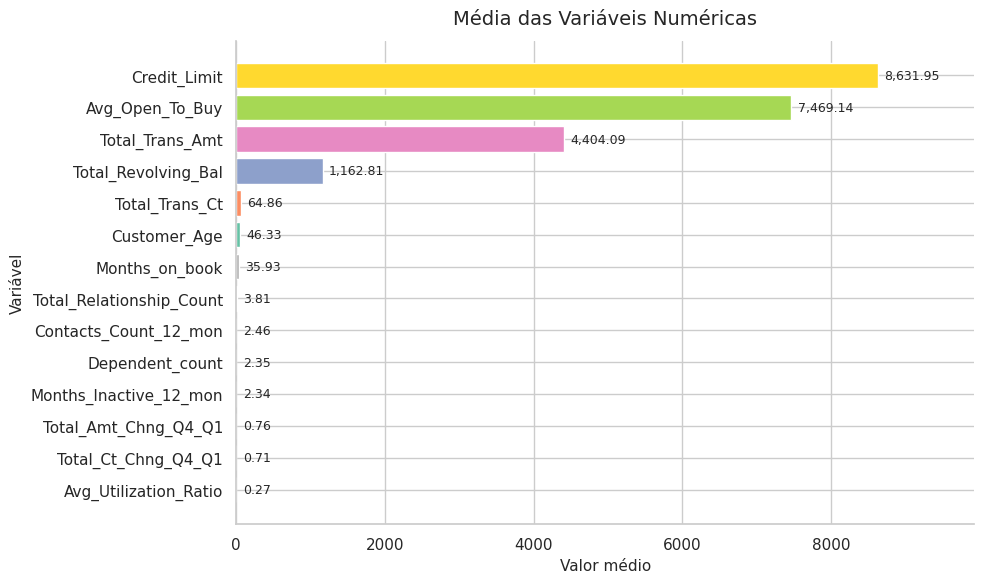

In [37]:
# Gráfico de barras horizontais — médias das variáveis numéricas
medias = df.select_dtypes(include='number').mean().round(2).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
cores = sns.color_palette('Set2', n_colors=len(medias))
barras = ax.barh(medias.index, medias.values, color=cores, edgecolor='white')

# Anotação dos valores
for barra, valor in zip(barras, medias.values):
    ax.text(
        barra.get_width() + medias.max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f'{valor:,.2f}',
        va='center', fontsize=9
    )

ax.set_title('Média das Variáveis Numéricas', fontsize=14, pad=12)
ax.set_xlabel('Valor médio', fontsize=11)
ax.set_ylabel('Variável', fontsize=11)
ax.set_xlim(0, medias.max() * 1.15)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


O gráfico evidencia a grande **diferença de escala** entre as variáveis numéricas. `Credit_Limit` (média `8.631,95`) e `Avg_Open_To_Buy` (média `7.469,14`) dominam o eixo horizontal por serem valores financeiros absolutos, enquanto variáveis como `Avg_Utilization_Ratio` (`0,27`), `Total_Ct_Chng_Q4_Q1` (`0,71`) e `Total_Amt_Chng_Q4_Q1` (`0,76`) são praticamente invisíveis na mesma escala.

Essa diferença de escala é um problema para muitos algoritmos de machine learning que comparam os valores das variáveis diretamente: uma variável com valores na casa dos milhares acaba tendo muito mais influência do que uma variável com valores entre 0 e 1, mesmo que as duas sejam igualmente importantes. Por isso, será necessário aplicar **normalização ou padronização** no Bloco 5, técnicas que colocam todas as variáveis em uma escala comparável.

Outra observação: `Credit_Limit` e `Avg_Open_To_Buy` têm médias muito próximas (`8.631` vs `7.469`), o que faz sentido, pois `Avg_Open_To_Buy = Credit_Limit − Total_Revolving_Bal`, quando o saldo devedor é baixo, o limite disponível fica próximo do limite total. Esse par provavelmente terá forte relação entre si, o que veremos na matriz de correlação (Seção 4.7).

### Desvio Padrão

O desvio padrão mede o quanto os valores se afastam da média: quanto maior, mais espalhados estão os dados. Quando o desvio padrão é parecido com (ou maior do que) a própria média, isso indica que os dados têm uma distribuição muito irregular, com muitos valores baixos e alguns poucos valores muito altos, ou vice-versa.

Observações a partir do `describe()`:
- **`Credit_Limit`** e **`Avg_Open_To_Buy`**, desvios padrão (≈ `9.089` e `9.091`) maiores que as próprias médias, confirmando que a distribuição é muito concentrada nos valores baixos com uma cauda longa de valores altos; ambas são candidatas à transformação logarítmica no Bloco 5
- **`Total_Trans_Amt`**, desvio de `3.397` sobre uma média de `4.404`, mostrando que os valores de transação variam bastante de cliente para cliente
- **`Total_Trans_Ct`**, desvio de `23,47` sobre média de `64,86`, variação proporcionalmente menor do que `Total_Trans_Amt`
- **`Avg_Utilization_Ratio`**, desvio de `0,28` sobre média de `0,27` (praticamente iguais), revelando que há clientes com utilização próxima de `0` e outros próximos de `1,0`, sinal de que a distribuição é irregular
- **Variáveis de contagem** (`Months_Inactive_12_mon`, `Contacts_Count_12_mon`, `Total_Relationship_Count`), desvios menores, valores mais concentrados em torno da média

In [38]:
# Desvios padrão das variáveis numéricas
desvios = df.describe().loc['std'].round(2)
print("Desvio padrão das variáveis numéricas:")
print(desvios)

Desvio padrão das variáveis numéricas:
Customer_Age                   8.02
Dependent_count                1.30
Months_on_book                 7.99
Total_Relationship_Count       1.55
Months_Inactive_12_mon         1.01
Contacts_Count_12_mon          1.11
Credit_Limit                9088.78
Total_Revolving_Bal          814.99
Avg_Open_To_Buy             9090.69
Total_Amt_Chng_Q4_Q1           0.22
Total_Trans_Amt             3397.13
Total_Trans_Ct                23.47
Total_Ct_Chng_Q4_Q1            0.24
Avg_Utilization_Ratio          0.28
Name: std, dtype: float64


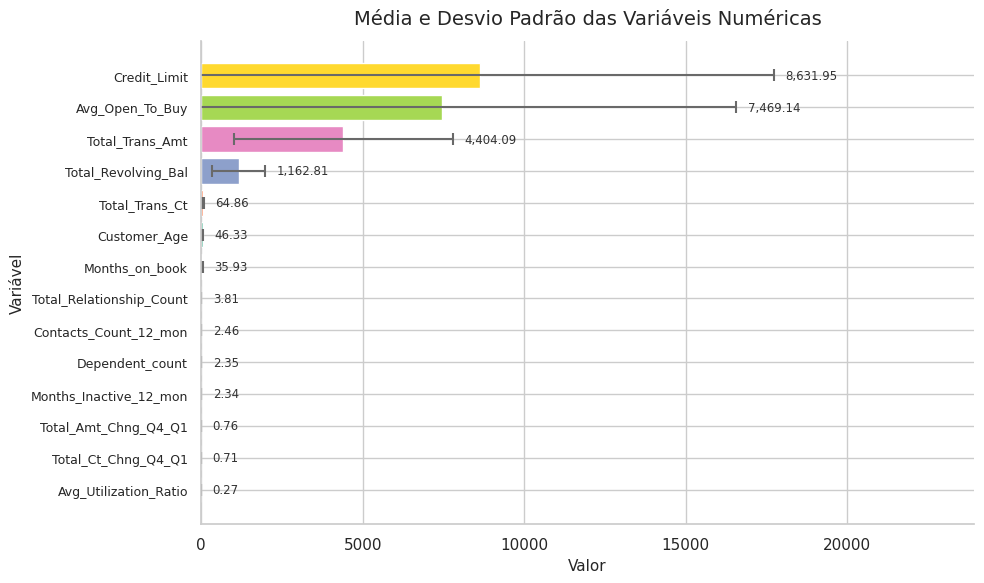

In [39]:
# Gráfico de barras com dispersão (média ± desvio padrão)
colunas_num = df.select_dtypes(include='number').columns.tolist()
medias_vals = df[colunas_num].mean()
desvios_vals = df[colunas_num].std()

# Ordenar por média crescente para melhor leitura
ordem = medias_vals.sort_values().index

fig, ax = plt.subplots(figsize=(10, 6))
cores = sns.color_palette('Set2', n_colors=len(ordem))

ax.barh(
    range(len(ordem)),
    medias_vals[ordem],
    xerr=desvios_vals[ordem],
    color=cores,
    edgecolor='white',
    capsize=4,
    error_kw={'elinewidth': 1.5, 'ecolor': 'dimgray', 'capthick': 1.5}
)

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels(ordem, fontsize=9)
ax.set_title('Média e Desvio Padrão das Variáveis Numéricas', fontsize=14, pad=12)
ax.set_xlabel('Valor', fontsize=11)
ax.set_ylabel('Variável', fontsize=11)

# Valores numéricos posicionados APÓS o bigode de erro (média + desvio + folga)
x_max = (medias_vals[ordem] + desvios_vals[ordem]).max()
folga = x_max * 0.02
for i, col in enumerate(ordem):
    x_anotacao = medias_vals[col] + desvios_vals[col] + folga
    ax.text(
        x_anotacao, i,
        f'{medias_vals[col]:,.2f}',
        va='center', ha='left', fontsize=8.5, color='#333333'
    )

ax.set_xlim(0, x_max * 1.35)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


O gráfico mostra a média de cada variável como uma barra horizontal, e os traços nas extremidades representam o intervalo de ± 1 desvio padrão, ou seja, onde fica a maior parte dos valores de cada variável.

O ponto mais importante aqui é que as barras de `Credit_Limit` e `Avg_Open_To_Buy` têm o intervalo de erro se estendendo para valores negativos (o traço da esquerda ultrapassa o zero), o que não faz sentido, limite de crédito não pode ser negativo. Isso acontece porque o desvio padrão dessas variáveis é maior do que a própria média, o que indica que elas não têm uma distribuição regular em formato de sino. Para essas variáveis, a média não é um bom resumo dos dados, e o desvio padrão deve ser interpretado com cuidado.

Em contraste, variáveis como `Total_Trans_Ct` (média `64,86`), `Customer_Age` (`46,33`) e `Months_on_book` (`35,93`) têm intervalos de erro proporcionais e centrados, o que indica distribuições mais regulares e simétricas.

`Avg_Utilization_Ratio` chama atenção: o desvio padrão (`0,28`) é praticamente igual à média (`0,27`), sugerindo que há dois grupos bem distintos de clientes, um que quase não usa o crédito (valores próximos de 0) e outro com uso moderado a alto. Isso ficará mais claro nos histogramas da Seção 4.3.

## Histogramas das Variáveis Numéricas

Os histogramas revelam a **forma da distribuição** de cada variável numérica, informação que as estatísticas descritivas da Seção 4.2 apenas sugeriam. Enquanto média, mediana e desvio padrão descrevem propriedades pontuais, o histograma mostra visualmente se a distribuição é simétrica, assimétrica à direita (cauda longa para valores altos), bimodal (dois picos) ou se apresenta picos anômalos em valores específicos.

Cada histograma é plotado com sobreposição da curva **KDE** (*Kernel Density Estimate*), uma estimativa suavizada da densidade de probabilidade. A KDE facilita a leitura do formato geral da distribuição sem depender do número de bins escolhido, e é especialmente útil para identificar bimodalidade.

Com base nos achados da Seção 4.2, as principais suspeitas que os histogramas devem confirmar são:

- **`Credit_Limit`** e **`Avg_Open_To_Buy`**: assimetria à direita acentuada, desvio padrão superior à média indica cauda longa
- **`Avg_Utilization_Ratio`**: possível bimodalidade, Q1 (`0,02`) muito próximo de zero sugere concentração no extremo inferior, mas Q3 de `0,50` indica segundo grupo com utilização moderada
- **`Total_Revolving_Bal`**: possível pico em zero, mínimo de `0` e Q1 de apenas `359` indicam que parcela relevante dos clientes não carrega saldo devedor
- **`Total_Trans_Amt`** e **`Total_Trans_Ct`**: assimetria moderada à direita, diferença entre média e mediana confirma cauda superior
- **`Customer_Age`** e **`Months_on_book`**: distribuições mais próximas do normal, desvio proporcional à média e quartis simétricos ao redor da mediana

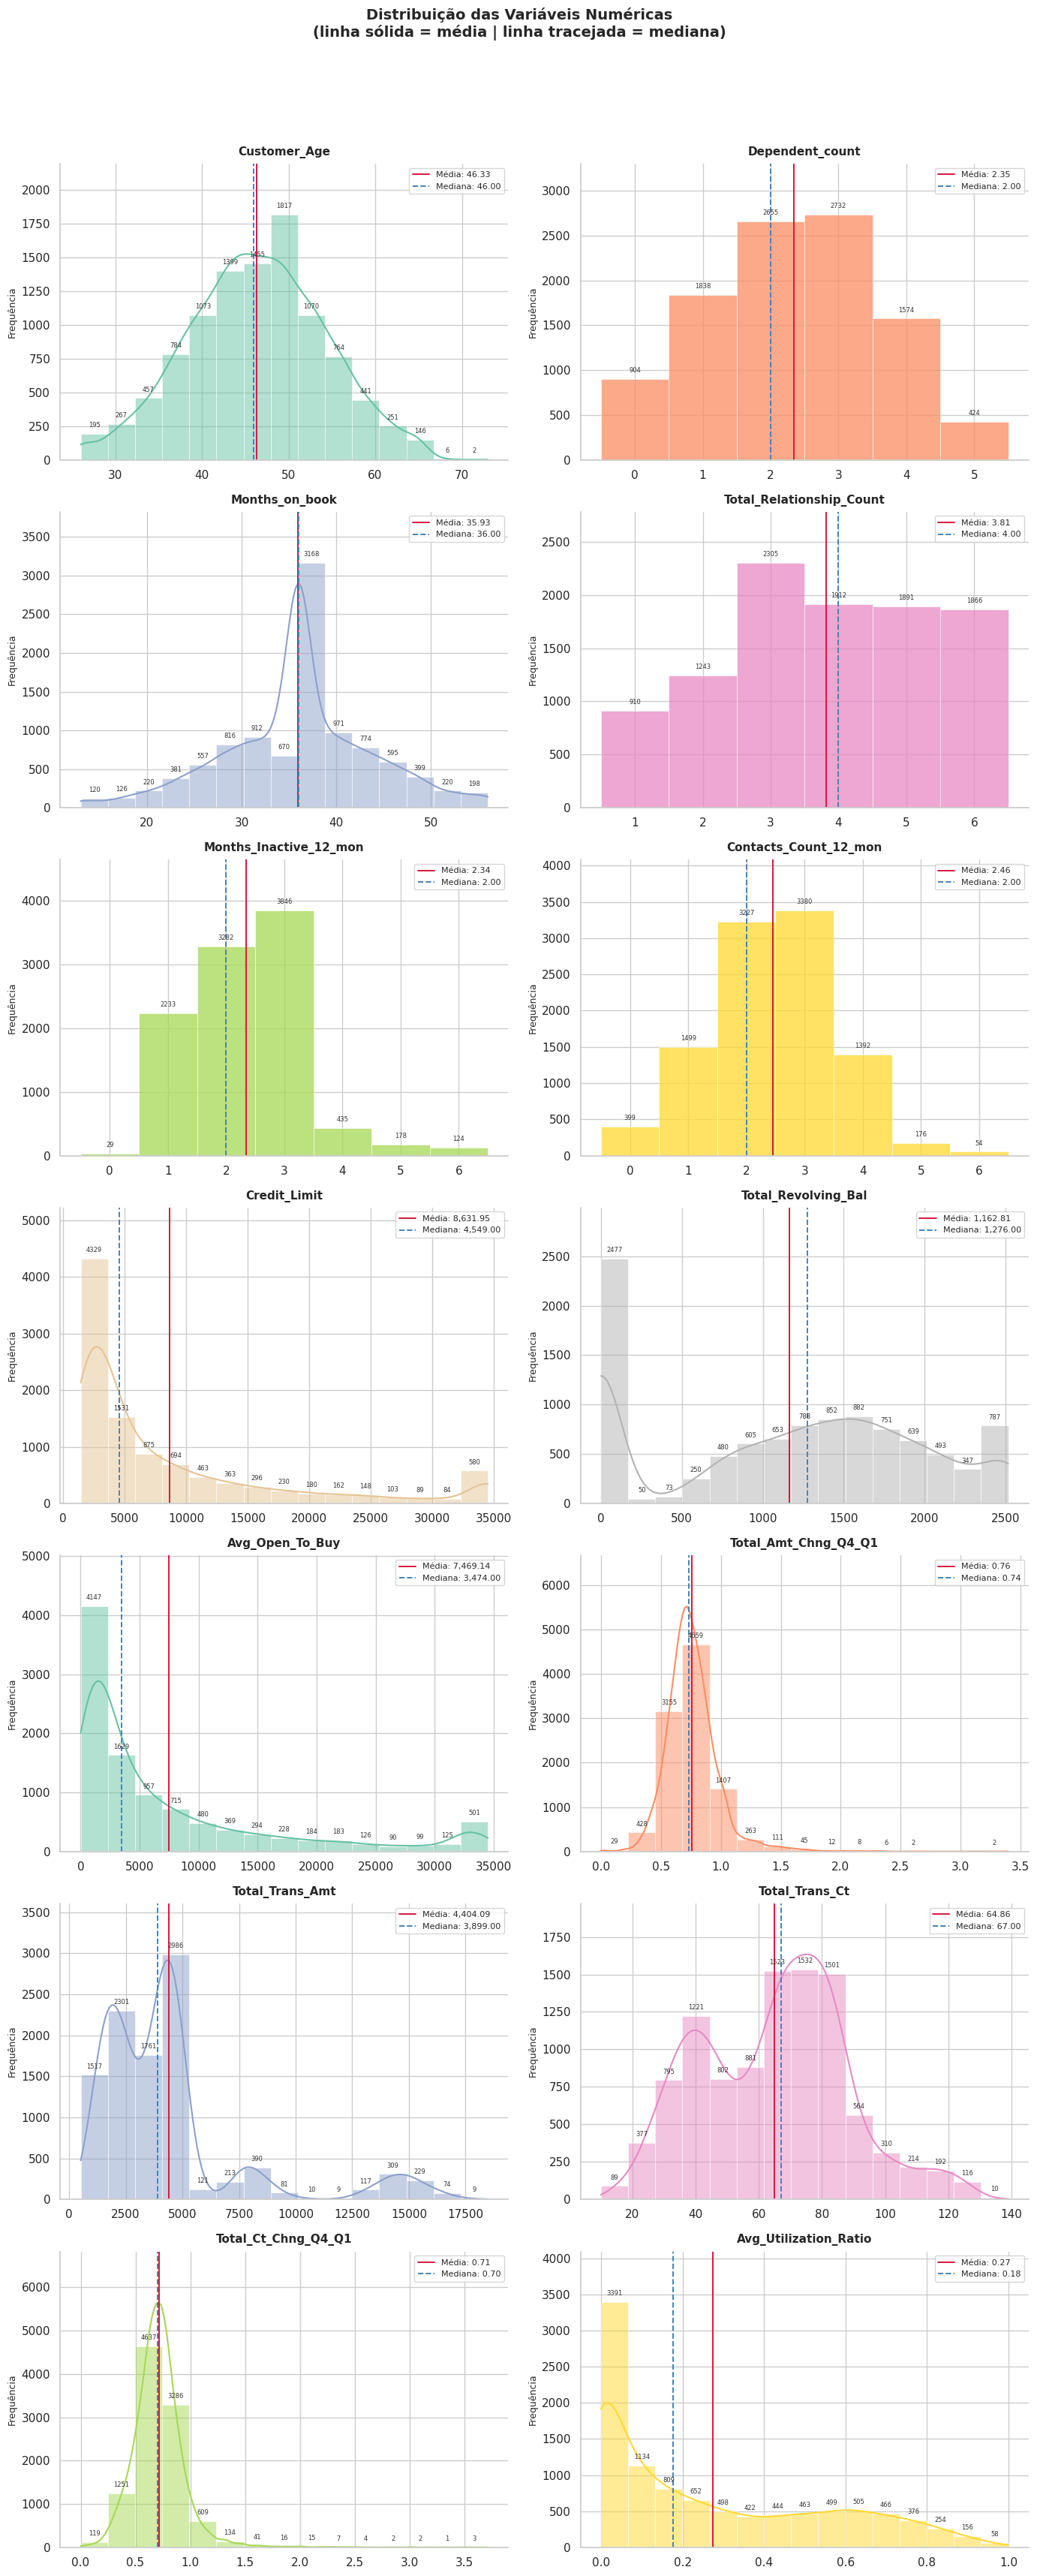

In [40]:
# Histogramas de todas as variáveis numéricas com curva KDE
colunas_num = df.select_dtypes(include='number').columns.tolist()

# Variáveis discretas: poucas categorias inteiras — KDE cria ondulações artificiais
colunas_discretas = {'Dependent_count', 'Total_Relationship_Count',
                     'Months_Inactive_12_mon', 'Contacts_Count_12_mon'}

n_cols = 2
n_rows = (len(colunas_num) + n_cols - 1) // n_cols  # 7 linhas para 14 variáveis

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 35))
axes = axes.flatten()

cores = sns.color_palette('Set2', n_colors=len(colunas_num))

for i, col in enumerate(colunas_num):
    media   = df[col].mean()
    mediana = df[col].median()
    eh_discreta = col in colunas_discretas

    if eh_discreta:
        # Variáveis discretas: sem KDE, barras centradas nos valores inteiros
        sns.histplot(df[col], kde=False, ax=axes[i], color=cores[i],
                     discrete=True, edgecolor='white', linewidth=0.4)
    else:
        sns.histplot(df[col], kde=True, ax=axes[i], color=cores[i], bins=15,
                     edgecolor='white', linewidth=0.4)

    axes[i].set_title(col, fontsize=11, fontweight='bold', pad=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência', fontsize=9)

    # Capturar ylim logo após o histograma (antes de adicionar anotações)
    y_top = axes[i].get_ylim()[1]

    # Valores numéricos em cima de cada barra
    for patch in axes[i].patches:
        altura = patch.get_height()
        if altura > 0:
            axes[i].text(
                patch.get_x() + patch.get_width() / 2,
                altura + y_top * 0.02,
                f'{int(altura)}',
                ha='center', va='bottom', fontsize=6, color='#333333'
            )

    # Expandir ylim para acomodar as anotações sem sobrepor a curva KDE
    axes[i].set_ylim(0, y_top * 1.15)

    # Linhas de referência: média (sólida) e mediana (tracejada)
    axes[i].axvline(media,   color='crimson',   linestyle='-',  linewidth=1.4,
                    label=f'Média: {media:,.2f}')
    axes[i].axvline(mediana, color='steelblue', linestyle='--', linewidth=1.4,
                    label=f'Mediana: {mediana:,.2f}')
    axes[i].legend(fontsize=8, loc='upper right')

# Remover eixos extras se o número de variáveis for ímpar
for j in range(len(colunas_num), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis Numéricas\n(linha sólida = média | linha tracejada = mediana)',
             fontsize=14, fontweight='bold')
sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Os histogramas mostram como os valores de cada variável se distribuem entre os `10.127` clientes. A seguir, os principais padrões observados:

**Variáveis com distribuição próxima do normal (formato de sino):**
- **`Customer_Age`**: a maioria dos clientes tem entre `41` e `52` anos, com pico em torno dos `46`. Poucos clientes têm menos de `30` ou mais de `65` anos. A distribuição é bastante simétrica.
- **`Months_on_book`**: a maioria está entre `31` e `40` meses (cerca de `3` anos de relacionamento com o banco). Valores extremos, clientes muito novos (menos de `20` meses) ou muito antigos (mais de `50` meses), são menos comuns.

**Variáveis discretas:**
- **`Dependent_count`**: a maioria dos clientes tem `2` ou `3` dependentes. Valores extremos (`0` ou `5`) são raros.
- **`Total_Relationship_Count`**: a maioria dos clientes possui `3`, `4` ou `5` produtos contratados com o banco. Ter apenas `1` produto é incomum.
- **`Months_Inactive_12_mon`**: o valor mais comum é `2` meses de inatividade no último ano. Poucas pessoas ficaram completamente ativas (`0` meses) ou muito inativas (`5` a `6` meses).
- **`Contacts_Count_12_mon`**: a maioria dos clientes entrou em contato com o banco `2` ou `3` vezes no ano. Valores de `0` ou acima de `4` são menos frequentes.

**Variáveis com concentração nos valores menores e cauda longa à direita:**
- **`Credit_Limit`**: a maioria dos clientes tem um limite de crédito baixo (próximo ao mínimo de `~R$1.400`). Poucos têm limites muito altos (acima de `R$20.000`), mas esses valores puxam a média para cima, por isso a média (`R$8.631`) fica bem acima da mediana (`R$4.549`). Essa diferença grande entre média e mediana é um sinal claro de que a distribuição não é simétrica.
- **`Avg_Open_To_Buy`**: apresenta o mesmo padrão de `Credit_Limit`, o que faz sentido, pois essa variável representa o limite disponível (quanto ainda pode ser gasto).

**`Total_Revolving_Bal`, pico de clientes sem dívida:**
A primeira barra, representando valores próximos de zero, é bem mais alta do que as demais. Isso indica que uma parcela considerável dos clientes não carrega saldo devedor no cartão, pagam a fatura integral todo mês. A partir daí, a frequência sobe e forma uma distribuição com pico em torno de `R$1.000` a `R$1.500`.

**`Total_Amt_Chng_Q4_Q1` e `Total_Ct_Chng_Q4_Q1`, variações de um trimestre para o outro:**
Ambas estão concentradas entre `0,5` e `1,0`, indicando que a maioria dos clientes manteve um padrão de gastos e transações relativamente estável entre os dois trimestres. A presença de poucos valores acima de `2,0` representa clientes com variações muito atípicas.

**`Total_Trans_Amt` e `Total_Trans_Ct`, dois perfis de uso:**
Nesses dois histogramas é possível enxergar dois grupos de clientes: um que usa o cartão com pouca frequência e valores baixos, e outro que usa com mais intensidade. Esse comportamento será importante para investigar a hipótese H5 (se a queda nas transações está ligada ao churn).

**`Avg_Utilization_Ratio`, muitos clientes quase não usam o crédito:**
A primeira barra é muito mais alta que as demais, mostrando que grande parte dos clientes usa muito pouco do limite disponível (próximo de `0%`). Um segundo grupo usa em torno de `20%` a `50%` do limite. Essa divisão reforça a hipótese H2, que investiga se baixa utilização do crédito está associada ao cancelamento do cartão.

## Distribuição das Variáveis Categóricas

Enquanto os histogramas da Seção 4.3 revelaram a forma das distribuições numéricas, as variáveis categóricas exigem uma abordagem diferente: verificar a **frequência absoluta e relativa** de cada categoria por meio de gráficos de contagem (`countplot`).

O dataset possui `5` variáveis categóricas: `Gender`, `Education_Level`, `Marital_Status`, `Income_Category` e `Card_Category`. Dessas, `3` (`Education_Level`, `Marital_Status` e `Income_Category`) contêm a categoria `"Unknown"`, que funciona como proxy de valores ausentes, conforme mencionado no Bloco 2 (Atributos do Dataset). Avaliar o peso relativo dessas categorias é essencial para decidir a estratégia de tratamento no pré-processamento (Bloco 5).

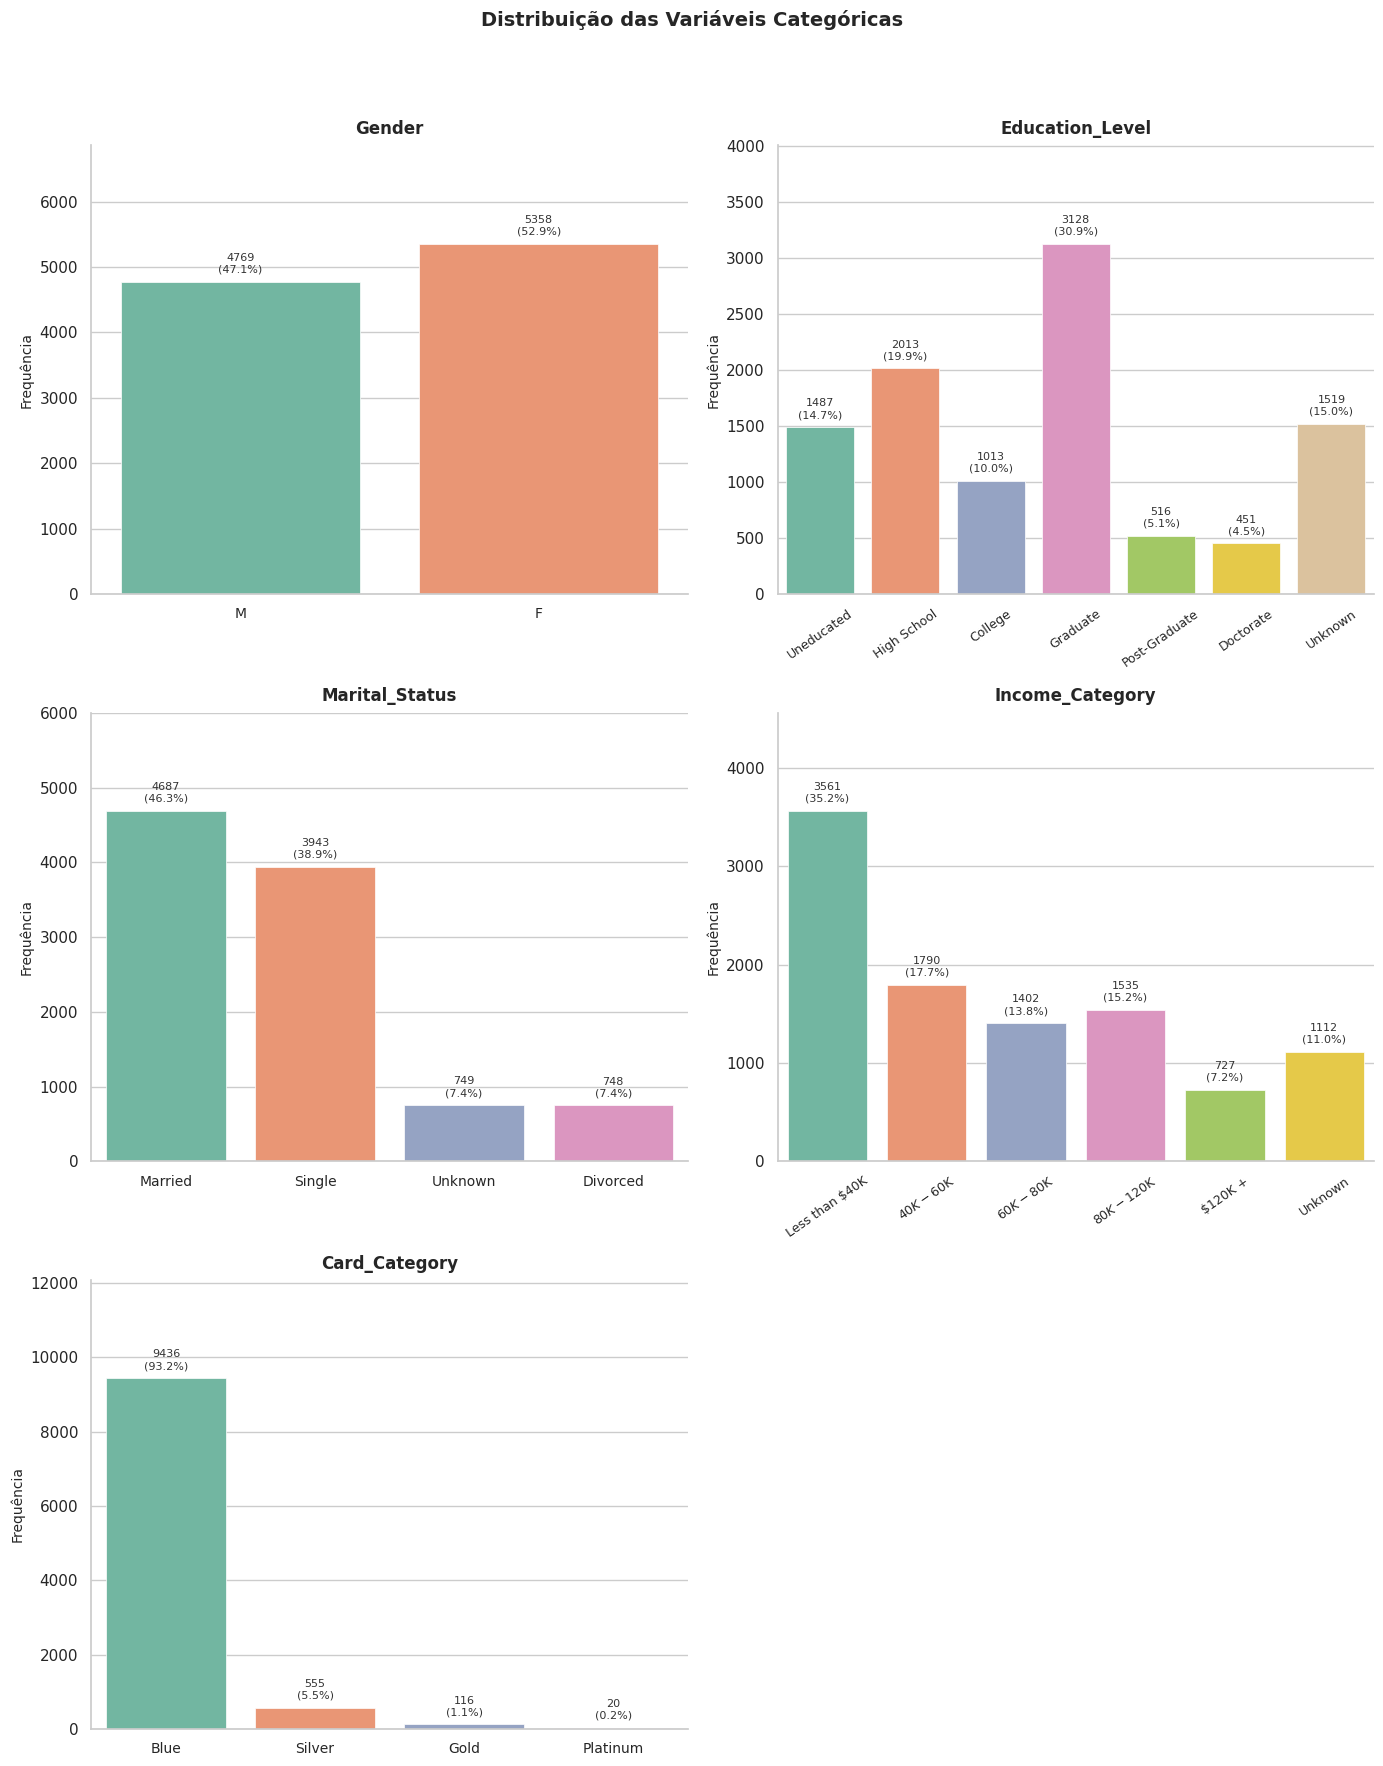

In [41]:
# Countplots das variáveis categóricas

categoricas = ['Gender', 'Education_Level', 'Marital_Status',
               'Income_Category', 'Card_Category']

# Ordem lógica para variáveis ordinais
ordens = {
    'Education_Level': ['Uneducated', 'High School', 'College', 'Graduate',
                        'Post-Graduate', 'Doctorate', 'Unknown'],
    'Income_Category': ['Less than $40K', '$40K - $60K', '$60K - $80K',
                        '$80K - $120K', '$120K +', 'Unknown'],
    'Card_Category': ['Blue', 'Silver', 'Gold', 'Platinum']
}

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    ordem = ordens.get(col, None)
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', order=ordem,
                  edgecolor='white', linewidth=0.5)

    axes[i].set_title(col, fontsize=12, fontweight='bold', pad=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência', fontsize=10)

    # Rotacionar labels para variáveis com muitas categorias
    if col in ['Income_Category', 'Education_Level']:
        axes[i].tick_params(axis='x', rotation=35, labelsize=9)
    else:
        axes[i].tick_params(axis='x', labelsize=10)

    # Capturar ylim após o countplot
    y_top = axes[i].get_ylim()[1]

    # Valores absolutos e percentuais em cima de cada barra
    total = len(df)
    for patch in axes[i].patches:
        altura = patch.get_height()
        if altura > 0:
            pct = altura / total * 100
            axes[i].text(
                patch.get_x() + patch.get_width() / 2,
                altura + y_top * 0.02,
                f'{int(altura)}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=8, color='#333333'
            )

    # Expandir ylim para acomodar as anotações (2 linhas de texto)
    y_top = axes[i].get_ylim()[1]
    axes[i].set_ylim(0, y_top * 1.22)

# Remover o eixo extra (5 categóricas em grid 3x2)
fig.delaxes(axes[5])

plt.suptitle('Distribuição das Variáveis Categóricas',
             fontsize=14, fontweight='bold')
sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Análise:** Os gráficos revelam padrões de composição relevantes para o problema de churn.

Em **Gender**, a divisão é quase equilibrada: `52,9%` mulheres e `47,1%` homens, sem dominância expressiva de um grupo.

Em **Education_Level**, a maioria possui graduação completa (`30,9%`), seguida por ensino médio (`19,9%`). Destaca-se a presença de `15,0%` de registros "Unknown", o maior percentual entre as variáveis categóricas com valores faltantes. Esse grupo será tratado no pré-processamento, conforme discutido no Bloco 2 (Atributos do Dataset).

Em **Marital_Status**, casados formam a maior fatia (`46,3%`), seguidos por solteiros (`38,9%`). Os grupos "Unknown" e "Divorced" têm participações muito próximas, ambos em torno de `7,4%`.

Em **Income_Category**, a faixa de menor renda ("Less than $40K") concentra `35,2%` dos clientes, o dobro da segunda categoria mais frequente ("$40K - $60K", com `17,7%`). Isso indica uma base de clientes predominantemente de renda baixa. O grupo "Unknown" responde por `11,0%`, exigindo atenção no pré-processamento.

Em **Card_Category**, a categoria "Blue" é amplamente dominante: `93,2%` dos clientes possuem esse cartão. As categorias Silver (`5,5%`), Gold (`1,1%`) e Platinum (`0,2%`) são muito minoritárias, o que pode limitar análises comparativas entre tipos de cartão.

## Boxplots: Variáveis Numéricas por Grupo (Target)

O **boxplot** (diagrama de caixa) sintetiza cinco estatísticas de uma variável numérica: mínimo, primeiro quartil (Q1), mediana, terceiro quartil (Q3) e máximo. Pontos fora dos *whiskers* (bigodes) são marcados como potenciais **outliers**. Essa representação compacta facilita a comparação entre grupos.

Nesta seção, as variáveis numéricas mais relevantes serão comparadas entre os dois grupos da variável-alvo (`Existing Customer` vs. `Attrited Customer`). O objetivo é identificar visualmente se a distribuição de cada variável difere entre clientes que cancelaram e os que permaneceram. Diferenças nas medianas, na dispersão ou na quantidade de outliers entre os grupos são sinais de que a variável pode ser discriminante para o churn.

As `6` variáveis selecionadas estão diretamente ligadas às hipóteses do Bloco 2 e aos padrões observados nos histogramas (Seção 4.3): `Total_Trans_Ct`, `Total_Trans_Amt`, `Months_Inactive_12_mon`, `Total_Revolving_Bal`, `Avg_Utilization_Ratio` e `Credit_Limit`.

Antes dos gráficos, a tabela `.describe()` agrupada por target fornece as estatísticas numéricas que os boxplots irão representar visualmente.

In [42]:
# Estatísticas descritivas agrupadas por status de churn
df.groupby('Attrition_Flag').describe().round(2)

Customer_Age                                             \
                         count   mean   std   min   25%   50%   75%   max   
Attrition_Flag                                                              
Attrited Customer       1627.0  46.66  7.67  26.0  41.0  47.0  52.0  68.0   
Existing Customer       8500.0  46.26  8.08  26.0  41.0  46.0  52.0  73.0   

                  Dependent_count        ... Total_Ct_Chng_Q4_Q1        \
                            count  mean  ...                 75%   max   
Attrition_Flag                           ...                             
Attrited Customer          1627.0  2.40  ...                0.69  2.50   
Existing Customer          8500.0  2.34  ...                0.83  3.71   

                  Avg_Utilization_Ratio                                     \
                                  count  mean   std  min   25%   50%   75%   
Attrition_Flag                                                               
Attrited Customer                1627.0  0.16  0.26  0.0  0.00  0.00  0.23   
Existing Customer                8500.0  0.30  0.27  0.0  0.06  0.21  0.53   

                         
                    max  
Attrition_Flag           
Attrited Customer  1.00  
Existing Customer  0.99  

[2 rows x 112 columns]

**Análise:** A tabela descritiva agrupada por `Attrition_Flag` permite comparar diretamente o comportamento dos clientes que cancelaram ("Attrited Customer") com os que permaneceram ("Existing Customer").

As diferenças mais expressivas estão nas variáveis de engajamento transacional. `Total_Trans_Ct` tem mediana de `43` para clientes que cancelaram, contra `71` para os ativos, uma redução de aproximadamente `39%`. O mesmo padrão aparece em `Total_Trans_Amt`: medianas de `2.329` e `4.100`, respectivamente, diferença de cerca de `43%`.

Nas variáveis de uso de crédito rotativo, a separação é ainda mais acentuada. Tanto `Total_Revolving_Bal` quanto `Avg_Utilization_Ratio` têm mediana `0,00` no grupo "Attrited", o que significa que pelo menos metade dos clientes que cancelaram não utilizava saldo rotativo algum. No grupo ativo, as medianas são `1.364` e `0,21`, respectivamente.

Em contraste, `Credit_Limit` apresenta a menor diferença entre os grupos: medianas de `4.178` (Attrited) e `4.643,50` (Existing), diferença inferior a `11%`, sugerindo que o limite de crédito, isoladamente, é um sinal fraco de churn.

Por fim, `Months_Inactive_12_mon` tem mediana levemente maior nos clientes que cancelaram (`3` versus `2`), coerente com a hipótese H1 levantada no Bloco 2.

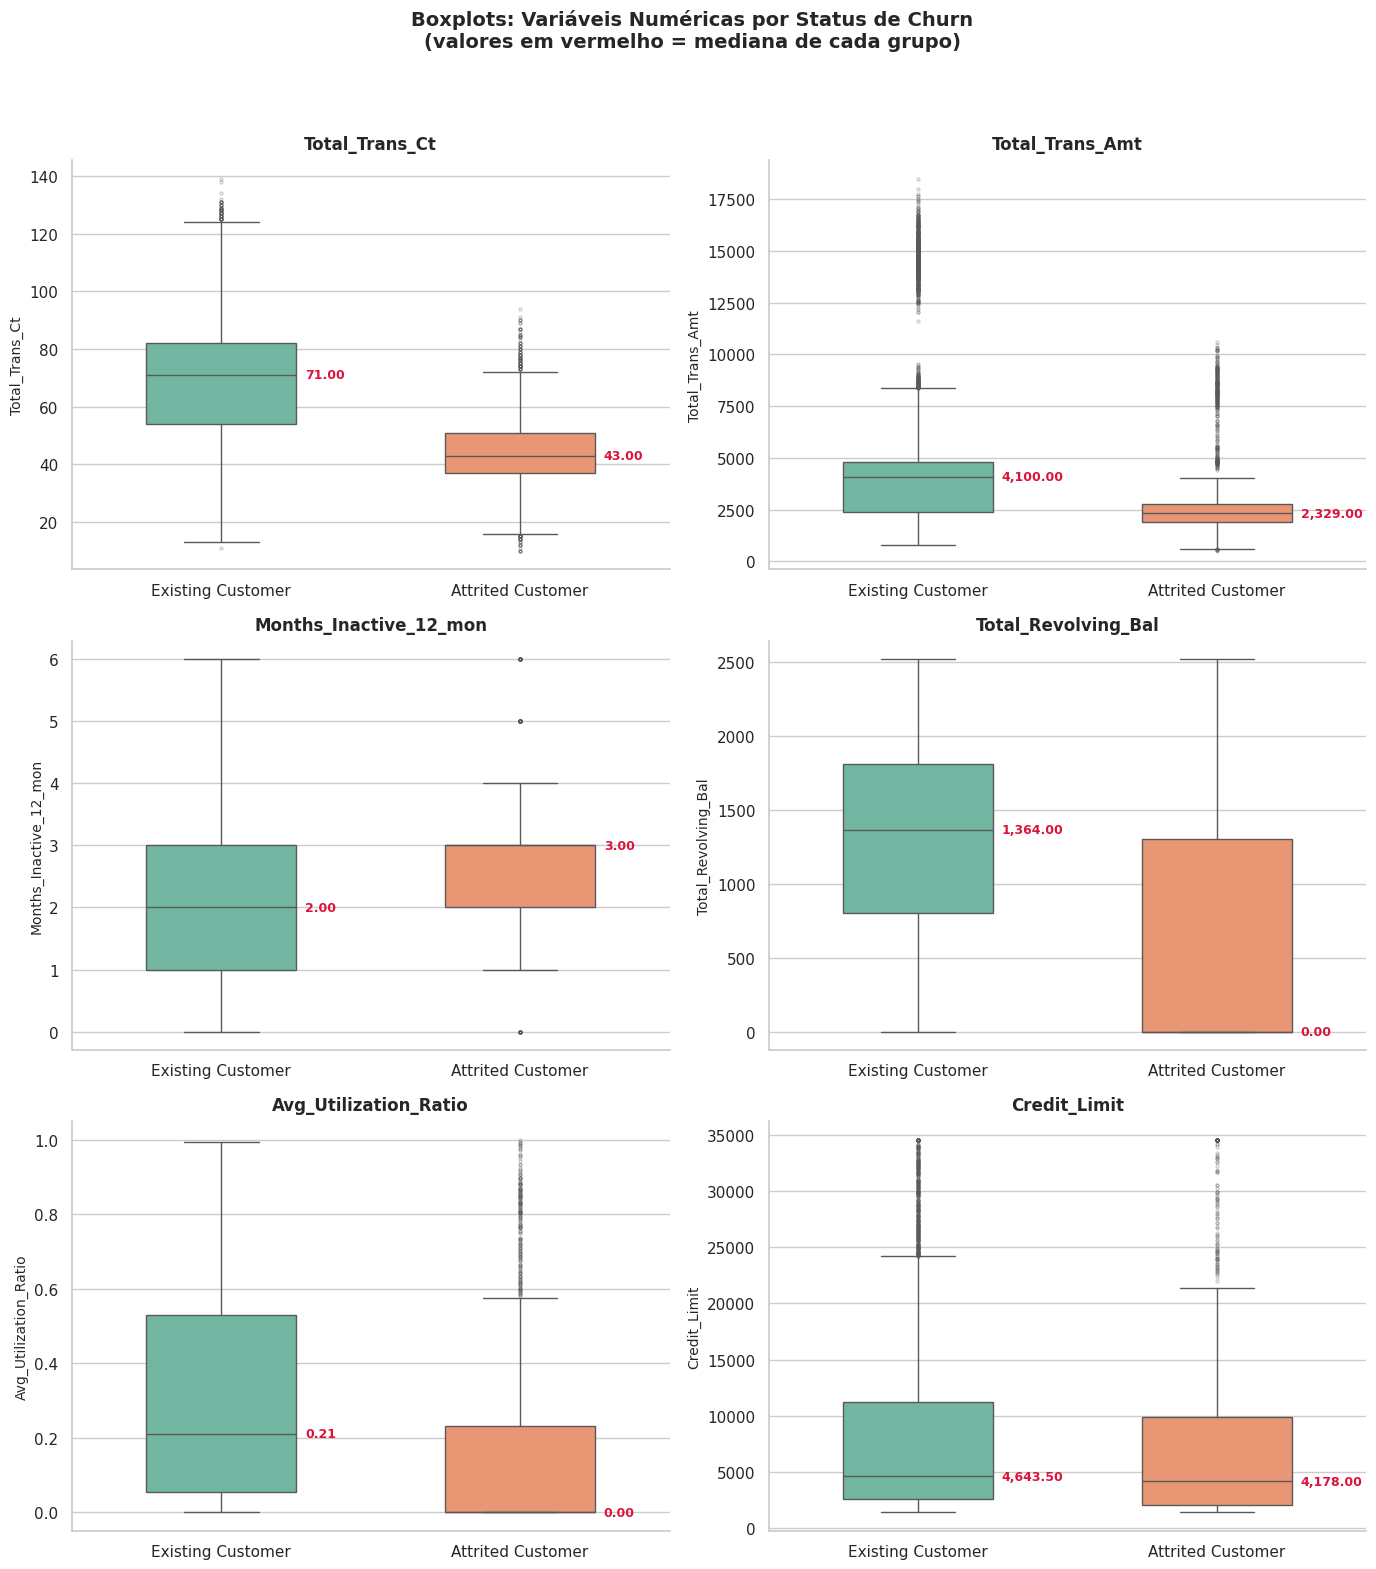

In [43]:
# Boxplots das variáveis numéricas selecionadas, agrupados por target

variaveis_boxplot = ['Total_Trans_Ct', 'Total_Trans_Amt',
                     'Months_Inactive_12_mon', 'Total_Revolving_Bal',
                     'Avg_Utilization_Ratio', 'Credit_Limit']

# Ordem fixa: garante que a anotacao de mediana apareça na caixa correta
ordem_grupos = ['Existing Customer', 'Attrited Customer']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(variaveis_boxplot):
    sns.boxplot(data=df, x='Attrition_Flag', y=col, ax=axes[i],
                palette='Set2', width=0.5, order=ordem_grupos,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))

    axes[i].set_title(col, fontsize=12, fontweight='bold', pad=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=10)

    # Anotar medianas — usar a mesma ordem do eixo x (ordem_grupos)
    medianas = df.groupby('Attrition_Flag')[col].median()
    for j, grupo in enumerate(ordem_grupos):
        axes[i].text(j + 0.28, medianas[grupo], f'{medianas[grupo]:,.2f}',
                     ha='left', va='center', fontsize=9,
                     fontweight='bold', color='crimson')

plt.suptitle('Boxplots: Variáveis Numéricas por Status de Churn\n'
             '(valores em vermelho = mediana de cada grupo)',
             fontsize=14, fontweight='bold')
sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Análise:** Os boxplots confirmam visualmente os padrões identificados na tabela descritiva da subseção anterior, e permitem avaliar também a sobreposição e a dispersão entre os grupos.

**Total_Trans_Ct** e **Total_Trans_Amt** apresentam a separação mais clara entre os grupos: as caixas mal se sobrepõem, com medianas de `43` e `71` para contagem de transações, e de `2.329` e `4.100` para valor total. São os sinais mais discriminativos observados até agora.

**Total_Revolving_Bal** e **Avg_Utilization_Ratio** mostram um comportamento peculiar nos clientes que cancelaram: o boxplot está colapsado no eixo inferior, com mediana `0` e Q1 também próximo de zero. Isso reforça que uma parcela expressiva desse grupo simplesmente não utilizava o crédito rotativo antes de cancelar, um padrão que se alinha à hipótese H2 (baixa utilização associada a maior churn).

**Months_Inactive_12_mon** exibe distribuição mais concentrada em ambos os grupos, com a mediana de "Attrited" (`3`) apenas um mês acima da de "Existing" (`2`). A diferença é pequena numericamente, mas consistente com H1.

**Credit_Limit** é a variável com menor poder discriminativo entre as seis: as distribuições dos dois grupos se sobrepõem amplamente, e a diferença de medianas é inferior a `11%`, como já notado na tabela. Isso sugere que o limite de crédito, por si só, não é um bom preditor de churn.